Nome: Felipe Apostolos Pereira Colohoridis

RA: 250397

Curso: 34 - Engenharia da Computação



# Ex04 - Filtragem de Imagens

Nesta atividade vamos entender a operação de convolução e o uso da mesma para filtragem de imagens. Testaremos o uso de **filtros suavizantes**, usados para a remoção de ruído, e **filtros aguçantes**, usados para detecção de bordas.  

- **Filtros suavizantes:** são aqueles que removem a nitidez da imagem fazendo uma média, aritmética ou ponderada, na janela do núcleo. O filtro ponderado suavizante mais comum é o da gaussiana. Filtros suavizantes são muito utilizados para eliminar ruído de uma imagem.

- **Filtros aguçantes:** são aqueles que realçam as bordas da imagem. Alguns dos filtros aguçantes comuns são: Filtro de Sobel, Filtro de Prewitt, Filtro Laplaciano.

Veja mais no notebook sobre [Filtragem no domínio espacial](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/07_Filtragem_no_dominio_espacial.ipynb)

In [151]:
# Importando as bibliotecas que serão utilizadas
import os
import random
import shutil

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

Download das imagens:

In [152]:
zip_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/FiltragemDeImagens.zip"

if not os.path.exists("FiltragemDeImagens.zip"):
    response = requests.get(zip_url)
    with open("FiltragemDeImagens.zip", mode="wb") as file:
        file.write(response.content)

if not os.path.exists("FiltragemDeImagens"):
    shutil.unpack_archive("FiltragemDeImagens.zip")

In [153]:
path = "FiltragemDeImagens/"

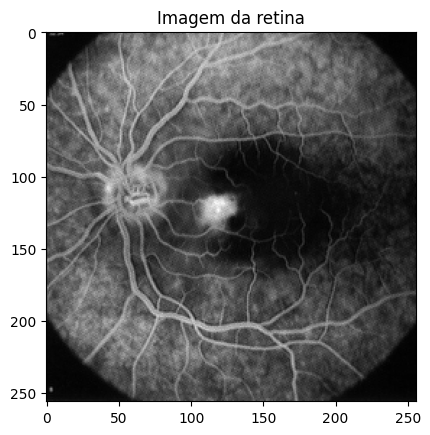

In [154]:
%matplotlib inline
f = mpimg.imread(path+'retina.tif')
plt.title('Imagem da retina')
plt.imshow(f,cmap='gray')

**ATENÇÃO** - as operações de filtragem alteram os valores e eles podem sair da faixa de 0 a 255. Portanto, fique atento à maneira como você está realizando as operações e visualizando os resultados. Algumas dicas:

- Uma boa prática é realizar as operações em ponto flutuante;
- Quando a visualização não corresponde ao esperado, desconfie que os valores sairam da escala e que os valores, de alguma maneira, estão sendo truncados.

## Parte 1 - Operação de convolução e filtro da média

### Exercício 1.1

Entenda o uso da operação de convolução e experimente usá-la para entender o filtro da média. Siga o seguinte roteiro:
- Crie uma imagem numérica pequena (7x7, por exemplo), crie um filtro de média (kernel 3x3) e use a função **convolve()** da biblioteca **scipy.ndimage** para realizar a filtragem. Verifique numericamente que a filtragem está correta;
- Repita a operação de filtragem na imagem da retina e visualize o resultado;
- Faça experimentos com a imagem da retina variando o tamanho do filtro e compare as imagens resultantes;
- Não se esqueça de comentar os métodos utilizados e resultados obtidos.

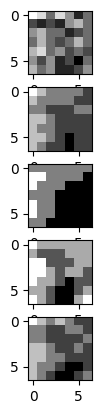

In [155]:
# Seu código aqui
import random
import scipy.ndimage as scimg

# Irá recortar uma área 7x7 aletória para obter uma imagem 7x7

# Para tanto, obtém 1 linha e 1 coluna para partir e pegar a imagem
number_aleatorio_1 = random.randint(0, len(f) - 7)
number_aleatorio_2 = random.randint(0, len(f[0]) - 7)

# Obtém a imagem 7x7
imagem_7x7 = f[number_aleatorio_1 : number_aleatorio_1 + 7, number_aleatorio_2 : number_aleatorio_2 + 7]

# Cria subplot pra plotar 5 imagens
a, b = plt.subplots(5, 1)

# Plota a imagem
b[0].imshow(imagem_7x7, cmap = 'gray')

# Cria um filtro 3x3 que devolve a média
filtro_3x3 = np.ones((3, 3))
filtro_3x3 = filtro_3x3/9

# Obtém convolução do filtro 3x3 e imagem e plota
result_3x3 = scimg.convolve(imagem_7x7, filtro_3x3)
b[1].imshow(result_3x3, cmap = 'gray')

# Cria filtro 5x5
filtro_5x5 = np.ones((5, 5))
filtro_5x5 = filtro_5x5/25

# Obtém convolução do filtro 5x5 e imagem e plota
result_5x5 = scimg.convolve(imagem_7x7, filtro_5x5)
b[2].imshow(result_5x5, cmap = 'gray')

# Cria filtro 2x2
filtro_2x2 = np.ones((2, 2))
filtro_2x2 = filtro_2x2/4

# Obtém convolução do filtro 2x2 e imagem e plota
result_2x2 = scimg.convolve(imagem_7x7, filtro_2x2)
b[3].imshow(result_2x2, cmap = 'gray')

# Cria filtro 3x3, mas o peso do pixel no centro vale 4 vezes mais que outros
filtro_3x3_diff = np.ones((3, 3))
filtro_3x3_diff = filtro_3x3_diff/12
filtro_3x3_diff[1][1] = filtro_3x3_diff[1][1] * 4

# Obtém convolução do filtro 3x3 diff e imagem e plota
result_3x3_diff = scimg.convolve(imagem_7x7, filtro_3x3_diff)
b[4].imshow(result_3x3_diff, cmap = 'gray')


# Comentário dos Resultados
Observando, os resultados, percebe-se que, conforme maior o filtro, maior a região de cor próxima. Em outras palavras, como o filtro é maior, a média obtida para os pixels vizinhos é muito similar, pois, por exemplo, no filtro 5x5, pixels vizinhos calculam seu novo valor com os mesmos 20 pixels e apenas 5 pixels diferentes (80% igual). Portanto, a imagem acaba contendo regiões maiores com pixels com valores similares. Ademais, ao colocar maior peso ao pixel no meio (o qual também é o pixel a ser mudado), as mudanças realizadas nas imagens são menores, pois grande parte do peso está no pixel a ser mudado, então a mudança de cor é menor.

### Exercício 1.2

Repita a operação de filtragem, desta vez variando também o modo de tratamento de borda da função **convolve()** - '*reflect*', '*constant*', '*nearest*', '*mirror*', '*wrap*' - explicando as diferenças encontradas. Dica, você só conseguirá visualizar as diferenças se aumentar o tamanho da máscara (filtro).

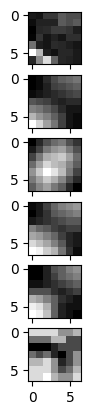

In [156]:
# Seu código aqui

# Irá recortar uma área 7x7 aletória para obter uma imagem 7x7

# Para tanto, obtém 1 linha e 1 coluna para partir e pegar a imagem
number_aleatorio_1 = random.randint(0, len(f) - 7)
number_aleatorio_2 = random.randint(0, len(f[0]) - 7)

# Obtém a imagem 7x7
imagem_7x7 = f[number_aleatorio_1 : number_aleatorio_1 + 7, number_aleatorio_2 : number_aleatorio_2 + 7]

# Cria subplot pra plotar 6 imagens
a, b = plt.subplots(6, 1)

# Plota a imagem
b[0].imshow(imagem_7x7, cmap = 'gray')

# Cria um filtro 5x5 que devolve a média
filtro_5x5 = np.ones((5, 5))
filtro_5x5 = filtro_5x5/25

# Obtém convolução do filtro 5x5 e imagem com modo 'reflect' e plota
result_11x11_reflect = scimg.convolve(imagem_7x7, filtro_5x5, mode = 'reflect')
b[1].imshow(result_11x11_reflect, cmap = 'gray')

# Obtém convolução do filtro 5x5 e imagem com modo 'constant' e plota
result_11x11_constant = scimg.convolve(imagem_7x7, filtro_5x5, mode = 'constant')
b[2].imshow(result_11x11_constant, cmap = 'gray')

# Obtém convolução do filtro 5x5 e imagem com modo 'nearest' e plota
result_11x11_nearest = scimg.convolve(imagem_7x7, filtro_5x5, mode = 'nearest')
b[3].imshow(result_11x11_nearest, cmap = 'gray')

# Obtém convolução do filtro 5x5 e imagem com modo 'mirror' e plota
result_11x11_mirror = scimg.convolve(imagem_7x7, filtro_5x5, mode = 'mirror')
b[4].imshow(result_11x11_mirror, cmap = 'gray')

# Obtém convolução do filtro 5x5 e imagem com modo 'wrap' e plota
result_11x11_wrap = scimg.convolve(imagem_7x7, filtro_5x5, mode = 'wrap')
b[5].imshow(result_11x11_wrap, cmap = 'gray')

# Comentário dos Resultados
Analisando os resultados, percebe-se que o tratamento de borda utilizados se comportam da seguinte forma:

Reflect -> Ao selecionar a região do filtro, para os pixels não definidos (forda da borda), a região é refletida (invertida verticalmente e/ou horizontalmente) e utilizado os pixels que entrarem na posição dos pixels não definidos.

Constant -> A fim de calcular a convolução das bordas, utiliza um valor constante para todos os pixels não definidos (fora da borda).

Nearest -> Utiliza o pixel mais próximo no lugar de pixels não definidos (fora da borda).

Mirror -> Atua de forma similar ao reflect, realizando espelhamento da região e utilizando os pixels espelhados.

Wrap -> Os pixels não definidos (fora da borda) são tratados como os pixels mais próximos e opostos já definidos. Em outras palavras, por exemplo, se há um filtro 3x3 e precisa definir o pixel do canto superior direito, a fim de definir o pixel a sua direita que será utilizado na convolução, usa o pixel oposto (esquerda) e fora do filtro, em outras palavras, o pixel que tem posição 2 pixels à esquerda do centro da região atual do kernel, mas, no caso de não haver sido definido, será utilizado o pixel mais próximo.

## Parte 2 - Filtro gaussiano e redução de ruído

### Exercício 2.1

Teste a propriedade de decomposição das máscaras da convolução, ou seja, crie um filtro gaussiano bi-dimensional (3,3) a partir de 2 filtros unidimensionais (3,1) e (1,3). Crie também o filtro bi-dimensional diretamente e cheque se os resultados são equivalentes. Comente os métodos utilizados.

kernel_media=
 [[0.111 0.111 0.111]
 [0.111 0.111 0.111]
 [0.111 0.111 0.111]]
kernel_gaussiana=
 [[0.111 0.111 0.111]
 [0.111 0.111 0.111]
 [0.111 0.111 0.111]]


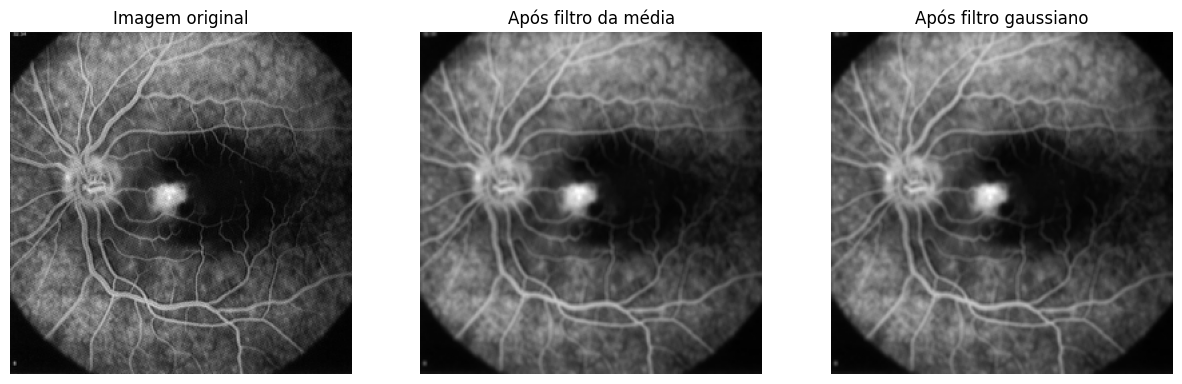

In [157]:
# Seu código aqui

# Filtro 3x3 da Média
k = np.ones((3,3))/9

f_conv_fmean = scimg.convolve(f, k)

# Gaussiana 2D (direta)
x, y = np.meshgrid(np.linspace(1,1,3), np.linspace(1,1,3))
d = x*x+y*y
sigma = 1.
gauss = (1./(2.*np.pi*sigma**2)) * np.exp(-d/(2.*sigma**2))
gauss = gauss/gauss.sum() # normalização

f_conv_fgauss = scimg.convolve(f, gauss)

print('kernel_media=\n', k.round(3))
print('kernel_gaussiana=\n', gauss.round(3))
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title('Imagem original')
plt.imshow(f, cmap='gray')
plt.axis('off')
plt.subplot(1,3,2)
plt.title('Após filtro da média')
plt.imshow(f_conv_fmean, cmap='gray')
plt.axis('off')
plt.subplot(1,3,3)
plt.title('Após filtro gaussiano')
plt.imshow(f_conv_fgauss, cmap='gray')
plt.axis('off');

# Comentário dos Métodos
Para obter o filtro bi-dimensional diretamente, apenas cria uma matriz de 1s com tamanho 3x3, divindo todos elementos por 9 para sua soma totalizar 1. Por outro lado, para obter um filtro gaussiano bi-dimensional parte-se de 2 matrizes [1, 1, 1], obtém-se seus valores 'x' e 'y' a partir da função "meshgrid". Após isso, utiliza-se a fórmula da gaussiana para obter o filtro e divide-se o kernel pela soma de seus elementos, a fim da soma da matriz resultar em, no máximo, 1 para evitar pixels superarem o limite de 255 e haver inversão de cores (pixels pretos se tornarem brancos).

### Exercício 2.2

Teste a aplicação de filtros suavizantes para redução de ruído: Adicione ruído gaussiano à imagem da retina (sugestão: use **np.random**) e depois tente remover o ruído com o filtro da média e com o filtro gaussiano. Você pode aumentar os filtros se quiser. Comente os métodos utilizados e resultados obtidos.

/tmp/ipykernel_9346/1090437356.py:16: RuntimeWarning: overflow encountered in scalar add
  f_ruidosa[index_random_1][index_random_2] = f_ruidosa[index_random_1][index_random_2] + ruido_random


kernel_gaussiana=
 [[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


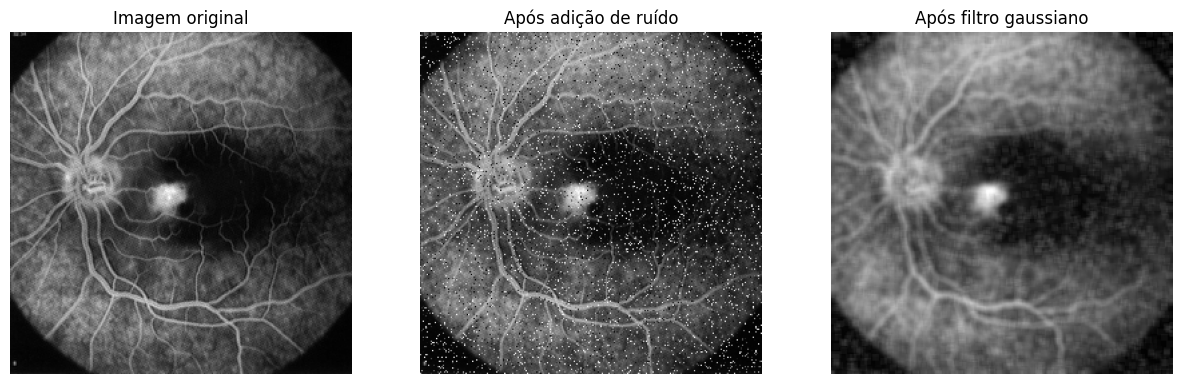

In [158]:
# Seu código aqui

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title('Imagem original')
plt.imshow(f, cmap='gray')

# Cria cópia da imagem
f_ruidosa = f.copy()

# Adiciona ruído
for i in range(int((f.shape[0] * f.shape[1]) * 0.1)):
  index_random_1 = random.randint(0, f.shape[0] - 1)
  index_random_2 = random.randint(0, f.shape[1] - 1)
  ruido_random = random.randint(0, 255)
  f_ruidosa[index_random_1][index_random_2] = f_ruidosa[index_random_1][index_random_2] + ruido_random

plt.axis('off')
plt.subplot(1,3,2)
plt.title('Após adição de ruído')
plt.imshow(f_ruidosa, cmap='gray')

# Gaussiana 2D (direta)
x, y = np.meshgrid(np.linspace(1,1,5), np.linspace(1,1,5))
d = x*x+y*y
sigma = 1.
gauss = (1./(2.*np.pi*sigma**2)) * np.exp(-d/(2.*sigma**2))
gauss = gauss/gauss.sum() # normalização

f_conv_fgauss = scimg.convolve(f_ruidosa, gauss)

print('kernel_gaussiana=\n', gauss.round(3))
plt.axis('off')
plt.subplot(1,3,3)
plt.title('Após filtro gaussiano')
plt.imshow(f_conv_fgauss, cmap='gray')
plt.axis('off');

# Comentário dos métodos
A fim de criar ruído na imagem, cria 3 valores aleatórios, 2 deles irão selecionar um pixel aleatório da imagem para ter seu valor alterado, enquanto o terceiro valor irá ser somado ao pixel. Tal método é realizado um total de 10% do número de pixels da imagem em um 'for', mais especificamente, para a imagem da retina, há 65 536 pixels, resultando em, no pior caso, 6 553 pixels tendo ruído adicionado. Após isso, pela gaussiana, é feito a convolução da média da imagem, resultando em uma imagem mais borrada, porém com menos ruído. Vale notar que quanto maior o filtro, menor será o ruído final, porém mais borrada será a imagem. Ademais, caso haja muito ruído, tal como mais de 50% da imagem ser ruído, torna-se inviável tentar restaurá-la.

## Parte 3 - Filtro de Sobel e detecção de bordas

Existem vários filtros que procuram realçar as bordas da imagem. Um dos mais conhecidos é o Operador Sobel, composto por uma máscara vertical (Sv) e uma máscara horizontal (Sh).

In [159]:
Sv = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
print('Sv =\n',Sv)

Sh = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])
print('Sh =\n',Sh)

Sv =
 [[ 1  0 -1]
 [ 2  0 -2]
 [ 1  0 -1]]
Sh =
 [[ 1  2  1]
 [ 0  0  0]
 [-1 -2 -1]]


Para detectar bordas de uma imagem usando o Filtro de Sobel, precisamos fazer a filtragem da imagem usando tanto a máscara vertical, quanto a horizontal. No final, acabaremos com 2 imagens resultantes, uma reforçando as bordas verticais e outra reforçando as bordas horizontais, como exemplificado abaixo.

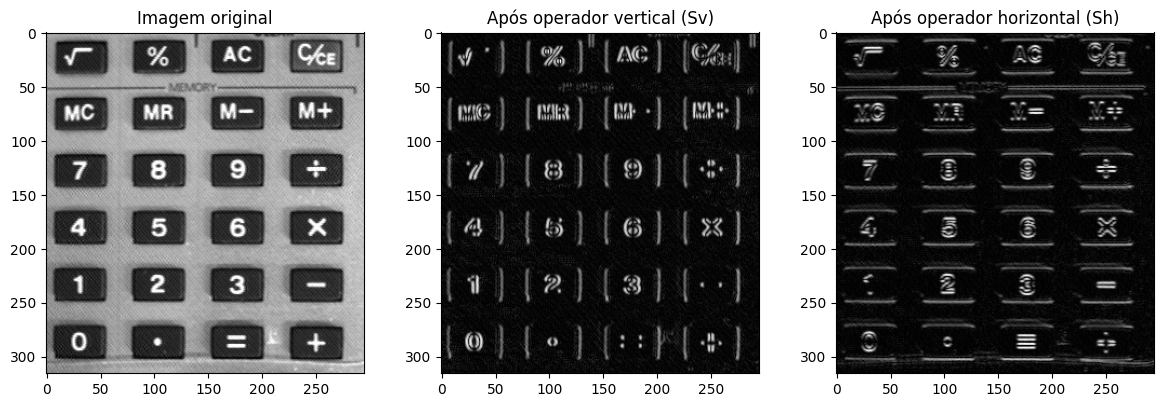

In [160]:
img = mpimg.imread(path+'keyb.tif')
img_sv = mpimg.imread(path+'keyb_sv.tif')
img_sh = mpimg.imread(path+'keyb_sh.tif')

fig, axs = plt.subplots(1,3, figsize=(12, 4))
plt.tight_layout()

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('Imagem original')

plt.subplot(132)
plt.imshow(img_sv,cmap='gray')
plt.title('Após operador vertical (Sv)')

plt.subplot(133)
plt.imshow(img_sh,cmap='gray')
plt.title('Após operador horizontal (Sh)');

### Exercício 3.1 - Visualizando as bordas verticais e horizontais em 2 imagens separadas

Experimente filtrar as imagens abaixo com os Filtros de Sobel vertical e horizontal e visualize o resultado. Para cada imagem, você deve obter uma imagem fitrada pelo Filtro de Sobel vertical - **fv** - e uma imagem filtrada pelo Filtro de Sobel horizontal - **fh**. Comente sobre os resultados obtidos. As imagens geradas estão de acordo com o exemplo apresentado para a imagem da calculadora? Em caso negativo, explique o porquê e tente fazer com que as imagens fiquem mais semelhantes.

In [161]:
img1 = mpimg.imread(path+'retina.tif')

Sv =
 [[ 1  0 -1]
 [ 2  0 -2]
 [ 1  0 -1]]
Sh =
 [[ 1  2  1]
 [ 0  0  0]
 [-1 -2 -1]]


Text(0.5, 1.0, 'Após operador horizontal (Sh)')

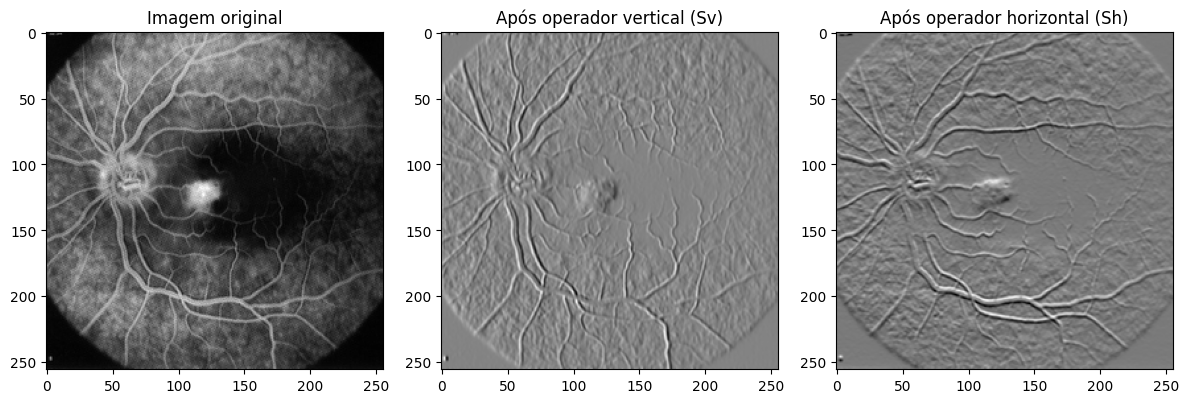

In [162]:
# Seu código aqui

# Definição de filtros
Sv1 = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
print('Sv =\n', Sv1)

Sh1 = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])
print('Sh =\n', Sh1)

# Filtragem
img1 = img1.astype(float)
img_sv1 = scimg.convolve(img1, Sv1)
img_sh1 = scimg.convolve(img1, Sh1)

# Plotagem
fig, axs = plt.subplots(1,3, figsize = (12, 4))
plt.tight_layout()

plt.subplot(131)
plt.imshow(img1, cmap = 'gray')
plt.title('Imagem original')

plt.subplot(132)
plt.imshow(img_sv1, cmap = 'gray')
plt.title('Após operador vertical (Sv)')

plt.subplot(133)
plt.imshow(img_sh1, cmap = 'gray')
plt.title('Após operador horizontal (Sh)')

# Comentário dos Resultados
Inicialmente, percebe-se ruído na imagem e, portanto, transforma a img1 em matriz de float para realizar a convolução. Todavia, mesmo após eliminar o ruído, os resultados observados diferem um pouco do esperado, pois, nas áreas onde há grandes regiões de pixels pretos, tal como nas bordas, esperava-se que o pixel resultante fosse resultar em pixel próximo de 0. Tal fenômeno se deve aos kernels vertical e horizontal de Sobel resultar na soma de 3 pixels vizinhos (com peso aplicado) e subtração de outros 3 pixels vizinhos (com peso aplicado) e, no caso desses pixels terem valores similares, o resultado iria beirar a 0.

In [163]:
img2 = mpimg.imread(path+'cameraman.tif')

Sv =
 [[ 1  0 -1]
 [ 2  0 -2]
 [ 1  0 -1]]
Sh =
 [[ 1  2  1]
 [ 0  0  0]
 [-1 -2 -1]]


Text(0.5, 1.0, 'Após operador horizontal (Sh)')

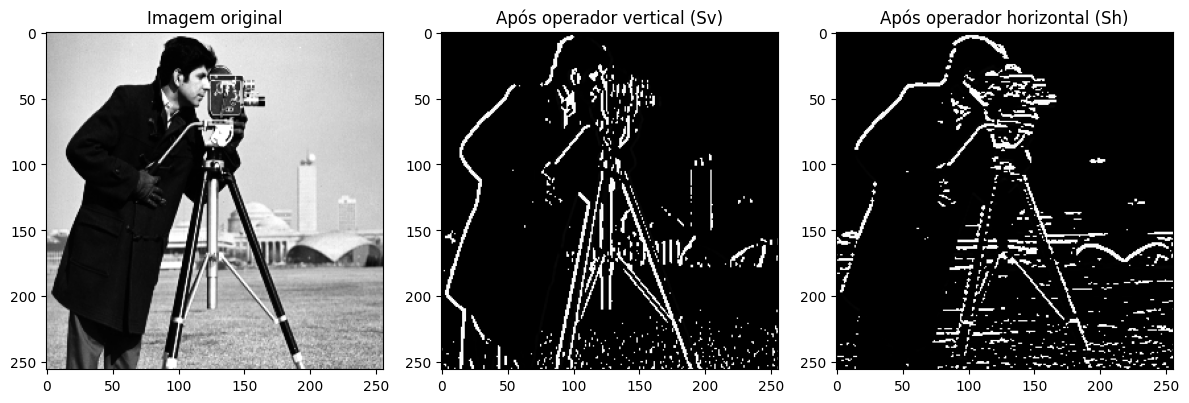

In [164]:
# Seu código aqui

# Definição de filtros
Sv2 = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
print('Sv =\n', Sv2)

Sh2 = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])
print('Sh =\n', Sh2)

# Filtragem
Sv2 = Sv2/100
Sh2 = Sh2/100
img_sv2 = scimg.convolve(img2, Sv2)
img_sh2 = scimg.convolve(img2, Sh2)

# Plotagem
fig, axs = plt.subplots(1, 3, figsize = (12, 4))
plt.tight_layout()

plt.subplot(131)
plt.imshow(img2, cmap = 'gray')
plt.title('Imagem original')

plt.subplot(132)
plt.imshow(img_sv2, cmap = 'gray')
plt.title('Após operador vertical (Sv)')

plt.subplot(133)
plt.imshow(img_sh2, cmap = 'gray')
plt.title('Após operador horizontal (Sh)')

# Comentário dos Resultados
Para a imagem 2, inicialmente, realiza o mesmo procedimento daquele realizado na imagem 1, porém nota-se alguns possíveis problemas para a aplicação do filtro Sobel. Por exemplo, o casaco do fotógrafo e o céu, ambos contém uma mistura de pixels pretos e brancos que não deveriam existir, visto que as cores dos pixels são praticamente iguais e, portanto, deveriam resultar em valor muito próximo de 0. Dessa maneira, aborda-se outra maneira, realizando a divisão do filtro por número alto (nesse caso 100), a fim de minimizar as chances de ocorrer inversão de pixels.

### Exercício 3.2 - Visualizando todas as bordas em uma única imagem

Para visualizar o resultado das 2 filtragens (horizontal e vertical) em uma única imagem, utilizamos a magnitude de Sobel. A função MagSobel (a ser implementada) possui como parâmetro a imagem de entrada e deve seguir a seguinte equação:

$$MagSobel = \sqrt{f_h^2 + f_v^2}$$

onde $f_h$ é a imagem de entrada convolvida com o operador de Sobel horizontal e $f_v$ é a imagem de entrada convolvida com o operador de Sobel vertical. Crie esta função e visualize a Magnitude de Sobel das imagens utilizadas no exercício 3.1.

Text(0.5, 1.0, 'Operador Magnitude Sobel 2 (MagSobel)')

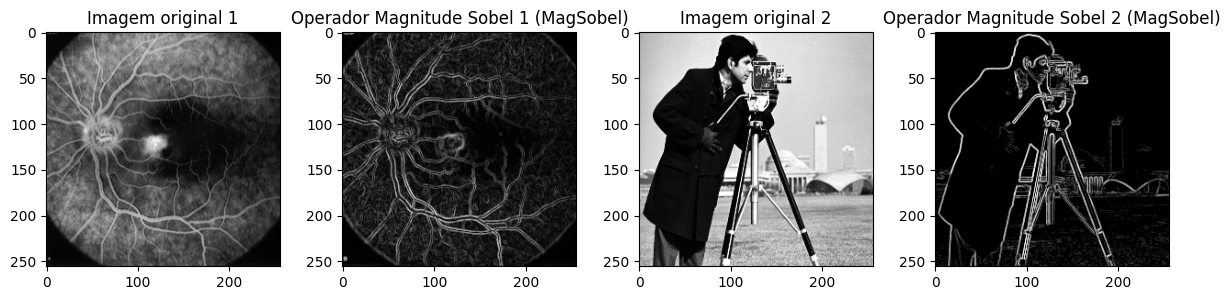

In [165]:
# Seu código aqui

# Obtém a nova imagem
img_sobel1 = ((img_sv1 ** 2) + (img_sh1 ** 2)) ** (1/2)
img_sobel2 = ((img_sv2 ** 2) + (img_sh2 ** 2)) ** (1/2)

# Plotagem
fig, axs = plt.subplots(1, 4, figsize = (12, 4))
plt.tight_layout()

plt.subplot(141)
plt.imshow(img1, cmap = 'gray')
plt.title('Imagem original 1')

plt.subplot(142)
plt.imshow(img_sobel1, cmap = 'gray')
plt.title('Operador Magnitude Sobel 1 (MagSobel)')

plt.subplot(143)
plt.imshow(img2, cmap = 'gray')
plt.title('Imagem original 2')

plt.subplot(144)
plt.imshow(img_sobel2, cmap = 'gray')
plt.title('Operador Magnitude Sobel 2 (MagSobel)')

# Comentário dos Resultados
Os resultados obtidos coincidem com o esperado, pois houve destacamento das bordas com cor branca enquanto o restante da imagem tem core mais escura. Portanto, pode-se concluir que o kernel de Sobel se comportou conforme esperado.

## Parte 4 - Aprendendo filtros com CNN (opcional para EA979)

Como vimos em sala de aula, as redes neurais convolucionais (CNNs, do inglês *convolutional neural networks*) têm como base as camadas convolucionais, um banco de filtros cujos pesos são aprendidos a partir de um gabarito para predição. Para entender melhor como isso funciona, vamos praticar com redes convolucionais bem simples e visualizar como os filtros são aprendidos por elas.

Vamos utilizar um conjunto de dados composto por 60 imagens de cidades, que servirão como entradas para a nossa rede. Além das imagens originais, temos também outros dois conjuntos de imagens, obtidos após a aplicação de dois tipos de filtros diferentes nas imagens originais (Dica: ambos os filtros aplicados foram filtros vistos anteriormente neste notebook). Essas imagens filtradas servirão como nosso gabarito para que a CNN possa aprender automaticamente qual filtro foi aplicado em cada conjunto de dados, ou seja, a rede vai tentar aprender qual o filtro necessário para obter o gabarito (imagem filtrada) a partir da entrada (imagem original).

**Para mais informações sobre redes convolucionais, exemplos e boas práticas, verifique os materiais de apoio disponibilizados no classroom. Lá você vai encontrar um tutorial teórico sobre CNN, além de tutoriais práticos disponibilizados no GitHub. Recomendamos utilizar a biblioteca PyTorch, que será utilizada novamente em exercícios futuros.**

Abaixo, visualizamos uma imagem aleatória do conjunto e suas respectivas versões filtradas.

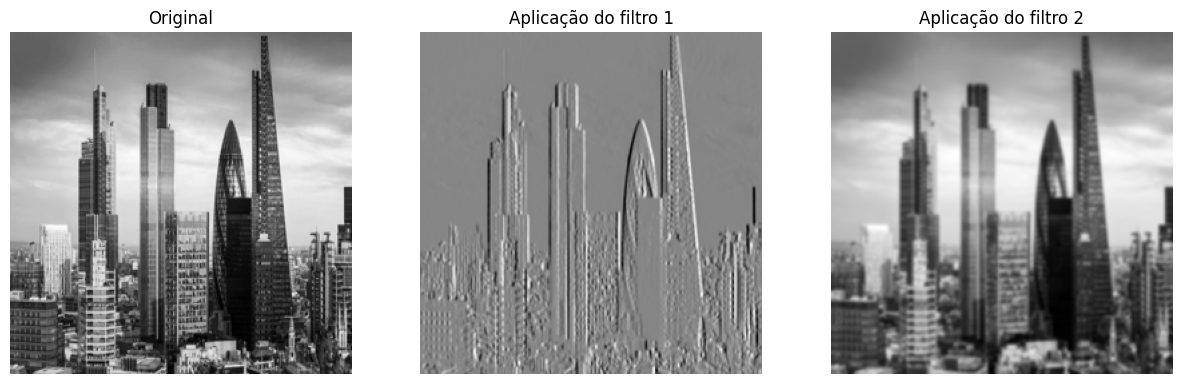

In [166]:
path_dataset = path + 'City_images/'
selec_img = random.randint(1, 60)

img_ori = Image.open(path_dataset+'imgs_originais/'+f'{selec_img}.tif')
img_f1 = Image.open(path_dataset+'imgs_filt1/'+f'{selec_img}.tif')
img_f2 = Image.open(path_dataset+'imgs_filt2/'+f'{selec_img}.tif')

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(np.array(img_ori), cmap='gray')
plt.axis('off')
plt.title('Original')
plt.subplot(132)
plt.imshow(np.array(img_f1), cmap='gray')
plt.axis('off')
plt.title('Aplicação do filtro 1')
plt.subplot(133)
plt.imshow(np.array(img_f2), cmap='gray')
plt.axis('off')
plt.title('Aplicação do filtro 2');

Para facilitar a visualização dos filtros aprendidos pela rede, vamos utilizar o código abaixo, que gera um **gif** a partir de um conjunto de arrays. Tente entender o código a partir do exemplo dado.

In [167]:
# Criando um conjunto de arrays para exemplificar o código
array_list = []
array_inicial = np.array([[0,0,0,0,0,0,0,0,0,0,0,0]]*6, dtype='uint8')
array_list.append(array_inicial)
for i in range(12):
    tmp = array_inicial.copy()
    tmp[2:4,:i+1] = 1
    array_list.append(tmp)

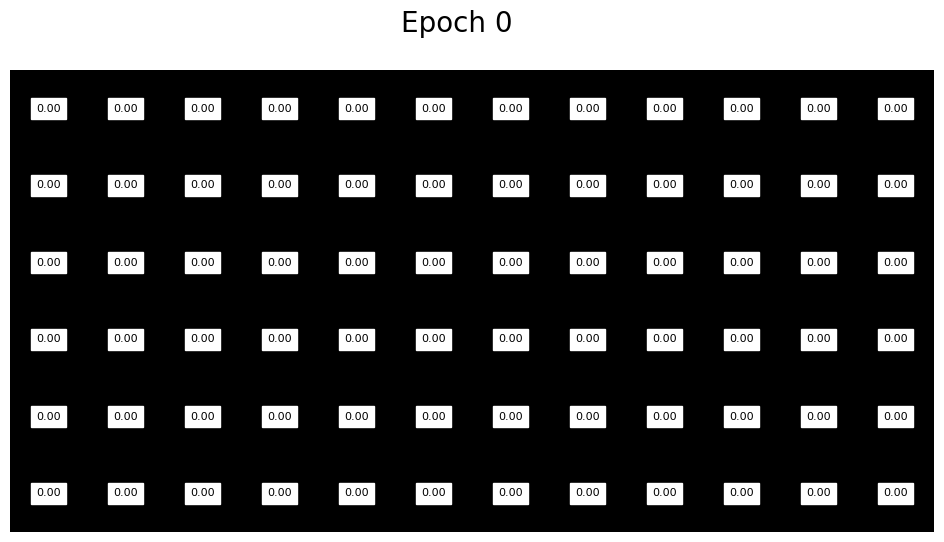

In [168]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Gif generation
images = np.array(array_list)
vmin = images.min()
vmax = images.max()
fig = plt.figure(figsize=(12,6))

# Function to update the image and add text annotations
def update(frame):
    plt.clf()  # Clear the previous plot
    fig.suptitle("Epoch {}".format(frame), fontsize=20) # Define the title
    plt.imshow(images[frame], vmin=vmin, vmax=vmax, cmap='gray') # Generate the image
    plt.axis('off')
    # Add text annotations
    for (i, j), value in np.ndenumerate(images[frame]):
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black', fontsize=8, backgroundcolor='white')

# Creating the animation
anim = FuncAnimation(fig, update, frames=len(images), interval=200)
# Displaying the animation in the notebook
html = anim.to_jshtml()
HTML(html)

### Exercício 4.1

Crie uma CNN composta por apenas uma camada convolucional com kernel de tamanho 3x3, que utilize as imagens originais como entrada e tenha como "gabarito" o primeiro conjunto de imagens filtradas (**imgs_filt1**). Você precisará definir uma função de loss, um otimizador para a rede e o número de épocas para treinamento. Então, treine a rede com as imagens especificadas, acompanhando os valores de loss a cada época. Você deve armazenar em uma lista os pesos do kernel da rede a cada época do treinamento.

Após o treinamento, visualize a progressão dos pesos do kernel utilizando o código de geração de **gif** dado anteriormente. Comente os métodos utilizados e resultados obtidos. A partir do **gif** obtido, você é capaz de dizer que filtro foi utilizado para gerar o conjunto de imagens da pasta **imgs_filt1**?

In [169]:
# Seu código aqui

### Exercício 4.2

Repita o processo realizado no exercício 5.1, mas dessa vez crie uma CNN composta por duas camadas convolucionais, a primeira com kernel de tamanho 1x5 e a segunda com kernel de tamanho 5x1. Você deve utilizar como "gabarito" o segundo conjunto de imagens filtradas (**imgs_filt2**). Armazene os pesos dos kernels da rede a cada época do treinamento em duas listas, uma para cada kernel.

Após o treinamento, visualize a progressão dos pesos de cada kernel utilizando o código de geração de **gif** dado anteriormente. Comente os métodos utilizados e resultados obtidos. A partir dos **gifs** obtidos, você é capaz de dizer que filtro foi utilizado para gerar o conjunto de imagens da pasta **imgs_filt2**?

In [170]:
# Seu código aqui